# Autoformer-lite Forecasting for CPI MoM Inflation

Clean Autoformer-style notebook for CPI forecasting. This is a lightweight Keras implementation inspired by Autoformer concepts: series decomposition, attention over seasonal component, optional date-time encoding, and Random Walk benchmark.

In [1]:
import os, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, Add, Concatenate, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import L1L2

plt.style.use("seaborn-v0_8-darkgrid")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()

DATA_DIR = os.path.join(os.getcwd(), "data", "processed")

OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", "step8_autoformer")
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_NAME = "Autoformer-lite"
MODEL_TAG = "autoformer"
LOSS_LABEL = "MSE"

In [2]:
target_var = "cpi_mom_inflation"
exog_vars = [
    "broad_money", "ppi_qoq", "wti", "gold",
    "policy_rate", "VNINDEX", "NIKKEI225", "USDVND"
]

df_raw = pd.read_csv(
    os.path.join(DATA_DIR, "cpi_forecast_selected_variables.csv"),
    index_col=0,
    parse_dates=True
)

df_all = df_raw[[target_var] + exog_vars].copy().dropna()

def classify_stationarity(series):
    s = pd.Series(series).dropna()
    adf_p = adfuller(s, autolag="AIC", regression="c")[1]
    return "I(0)" if adf_p < 0.05 else "I(1)"

transformed, name_map = {}, {}

for col in df_all.columns:
    status = classify_stationarity(df_all[col])
    if status == "I(0)":
        new_col = col
        transformed[new_col] = df_all[col]
    else:
        if col == "policy_rate" or (df_all[col] <= 0).any():
            new_col = f"diff_{col}"
            transformed[new_col] = df_all[col].diff()
        else:
            new_col = f"dlog_{col}"
            transformed[new_col] = np.log(df_all[col]).diff()
    name_map[col] = new_col

df = pd.DataFrame(transformed, index=df_all.index).dropna()
target_col = name_map[target_var]

feature_cols = [c for c in df.columns if c != target_col]

print(f"Data shape: {df.shape}")
print(f"Target after transform: {target_col}")
print(f"Target included in features: {target_col in feature_cols}")
print(f"Feature columns: {feature_cols}")

Data shape: (359, 9)
Target after transform: cpi_mom_inflation
Target included in features: False
Feature columns: ['dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'diff_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND']


In [3]:
def add_datetime_features(df):
    out = df.copy()
    month = out.index.month.values
    out["month_sin"] = np.sin(2 * np.pi * month / 12)
    out["month_cos"] = np.cos(2 * np.pi * month / 12)
    return out

# Set to True to use date-time encoding similar to MD-Autoformer idea.
USE_TIME_ENCODING = True
if USE_TIME_ENCODING:
    df_model = add_datetime_features(df)
    feature_cols_model = feature_cols + ["month_sin", "month_cos"]
else:
    df_model = df.copy()
    feature_cols_model = feature_cols.copy()

def create_supervised_sequences(df, target_col, feature_cols, window=12, horizon=1):
    X, y, dates = [], [], []
    values_X = df[feature_cols].values
    values_y = df[target_col].values
    index = df.index
    for i in range(window, len(df) - horizon + 1):
        X.append(values_X[i-window:i])
        y.append(values_y[i + horizon - 1])
        dates.append(index[i + horizon - 1])
    return np.array(X), np.array(y), pd.Index(dates)

window = 12
horizon = 1

X, y, y_dates = create_supervised_sequences(
    df=df_model,
    target_col=target_col,
    feature_cols=feature_cols_model,
    window=window,
    horizon=horizon
)

n = len(X)
train_end = int(0.70 * n)
val_end = int(0.80 * n)

X_train, y_train, dates_train = X[:train_end], y[:train_end], y_dates[:train_end]
X_val, y_val, dates_val = X[train_end:val_end], y[train_end:val_end], y_dates[train_end:val_end]
X_test, y_test, dates_test = X[val_end:], y[val_end:], y_dates[val_end:]

n_train, p, d = X_train.shape
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train.reshape(-1, d)).reshape(X_train.shape)
X_val_scaled = x_scaler.transform(X_val.reshape(-1, d)).reshape(X_val.shape)
X_test_scaled = x_scaler.transform(X_test.reshape(-1, d)).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

print("Supervised sequence creation and scaling")
print(f"X shape: {X.shape}")
print(f"Train: {X_train.shape}, {dates_train[0].date()} to {dates_train[-1].date()}")
print(f"Val:   {X_val.shape}, {dates_val[0].date()} to {dates_val[-1].date()}")
print(f"Test:  {X_test.shape}, {dates_test[0].date()} to {dates_test[-1].date()}")
print(f"Number of input features: {len(feature_cols_model)}")

Supervised sequence creation and scaling
X shape: (347, 12, 10)
Train: (242, 12, 10), 1996-02-01 to 2016-03-01
Val:   (35, 12, 10), 2016-04-01 to 2019-02-01
Test:  (70, 12, 10), 2019-03-01 to 2024-12-01
Number of input features: 10


In [4]:
from tensorflow.keras.layers import MultiHeadAttention, AveragePooling1D

class SeriesDecomposition(tf.keras.layers.Layer):
    def __init__(self, kernel_size=3, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
        self.avg = AveragePooling1D(pool_size=kernel_size, strides=1, padding="same")
    def call(self, x):
        trend = self.avg(x)
        seasonal = x - trend
        return seasonal, trend

def autoformer_block(x, d_model=32, num_heads=2, dropout=0.15, kernel_size=3):
    seasonal, trend = SeriesDecomposition(kernel_size=kernel_size)(x)
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout)(seasonal, seasonal)
    x = Add()([seasonal, attn])
    x = LayerNormalization()(x)
    ff = Dense(d_model * 2, activation="gelu")(x)
    ff = Dropout(dropout)(ff)
    ff = Dense(d_model)(ff)
    x = Add()([x, ff])
    x = LayerNormalization()(x)
    x = Add()([x, trend])
    return x

def build_autoformer_lite(window, n_features, d_model=32, num_heads=2, dropout=0.15, lr=0.0007):
    inputs = Input(shape=(window, n_features))
    x = Dense(d_model)(inputs)
    x = autoformer_block(x, d_model=d_model, num_heads=num_heads, dropout=dropout, kernel_size=3)
    x = autoformer_block(x, d_model=d_model, num_heads=num_heads, dropout=dropout, kernel_size=5)
    x = Lambda(lambda z: z[:, -1, :])(x)
    x = Dense(32, activation="relu", kernel_regularizer=L1L2(l1=5e-6, l2=1e-5))(x)
    x = Dropout(dropout)(x)
    outputs = Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse", metrics=["mae"])
    return model

model = build_autoformer_lite(window=window, n_features=len(feature_cols_model))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 12, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 12, 32)    │        352 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ series_decompositi… │ [(None, 12, 32),  │          0 │ dense[0][0]       │
│ (SeriesDecompositi… │ (None, 12, 32)]   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 32)    │      4,224 │ series_decomposi… │
│ (MultiHeadAttentio… │                   │            │ series_decomposi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12, 32)    │          0 │ series_decomposi… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 12, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 12, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 12, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 12, 32)    │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 12, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 12, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ series_decomposi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ series_decompositi… │ [(None, 12, 32),  │          0 │ add_2[0][0]       │
│ (SeriesDecompositi… │ (None, 12, 32)]   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 32)    │      4,224 │ series_decomposi… │
│ (MultiHeadAttentio… │                   │            │ series_decomposi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 12, 32)    │          0 │ series_decomposi… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 32)    │         64 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 12, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 12, 64)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 12, 32)    │      2,080 │ dropout_3[0][0] 

 Total params: 18,529 (72.38 KB)

 Trainable params: 18,529 (72.38 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=12, min_delta=1e-4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1)
]

history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=200,
    batch_size=16,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Best val loss: {min(history.history['val_loss']):.6f}")

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - loss: 1.8478 - mae: 1.0491 - val_loss: 0.6933 - val_mae: 0.6365 - learning_rate: 7.0000e-04
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.3689 - mae: 0.9200 - val_loss: 0.5735 - val_mae: 0.5892 - learning_rate: 7.0000e-04
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.2870 - mae: 0.8568 - val_loss: 0.4811 - val_mae: 0.5266 - learning_rate: 7.0000e-04
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1586 - mae: 0.7984 - val_loss: 0.4910 - val_mae: 0.5256 - learning_rate: 7.0000e-04
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9322 - mae: 0.7185 - val_loss: 0.4880 - val_mae: 0.5329 - learning_rate: 7.0000e-04
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9380 - mae: 0.7240 - val_loss: 0.5050 - val_mae: 0.5398 - learning_rate: 7.0000e-04
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8746 - mae: 0.6956 - val_loss: 0.4940 - val_mae: 0.5420 - learni


Test Results
R²:                 -0.3469
RMSE:               0.718648
MAE:                0.554428
Random Walk RMSE:   0.897799
Random Walk MAE:    0.628645
Model / RW RMSE:    0.8005
Mean Baseline RMSE: 0.619222
Model / Mean RMSE:  1.1606


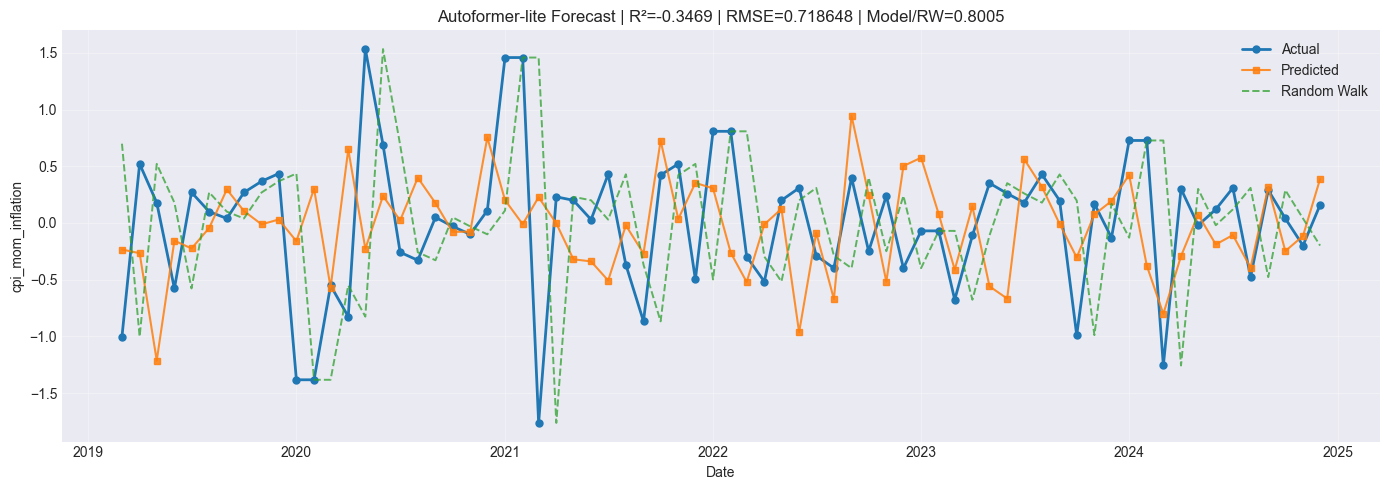

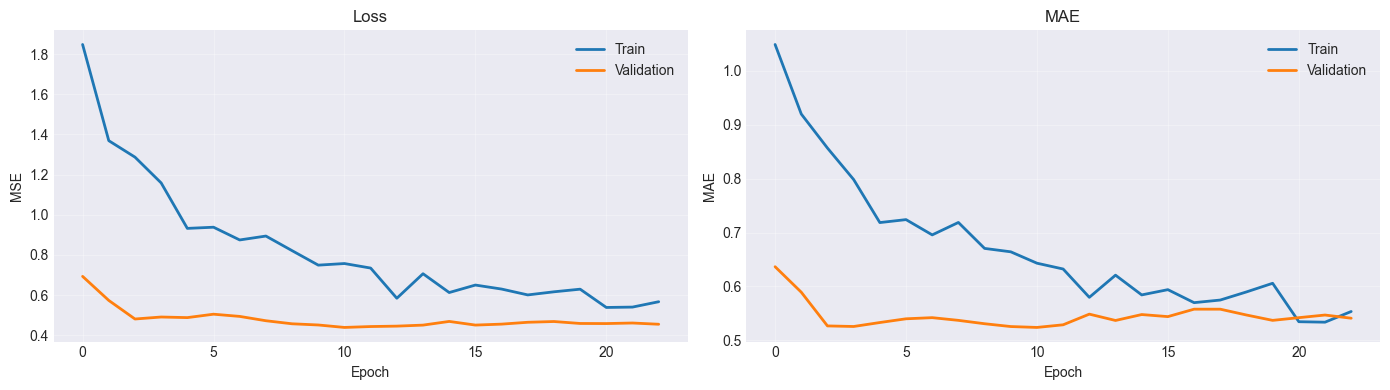

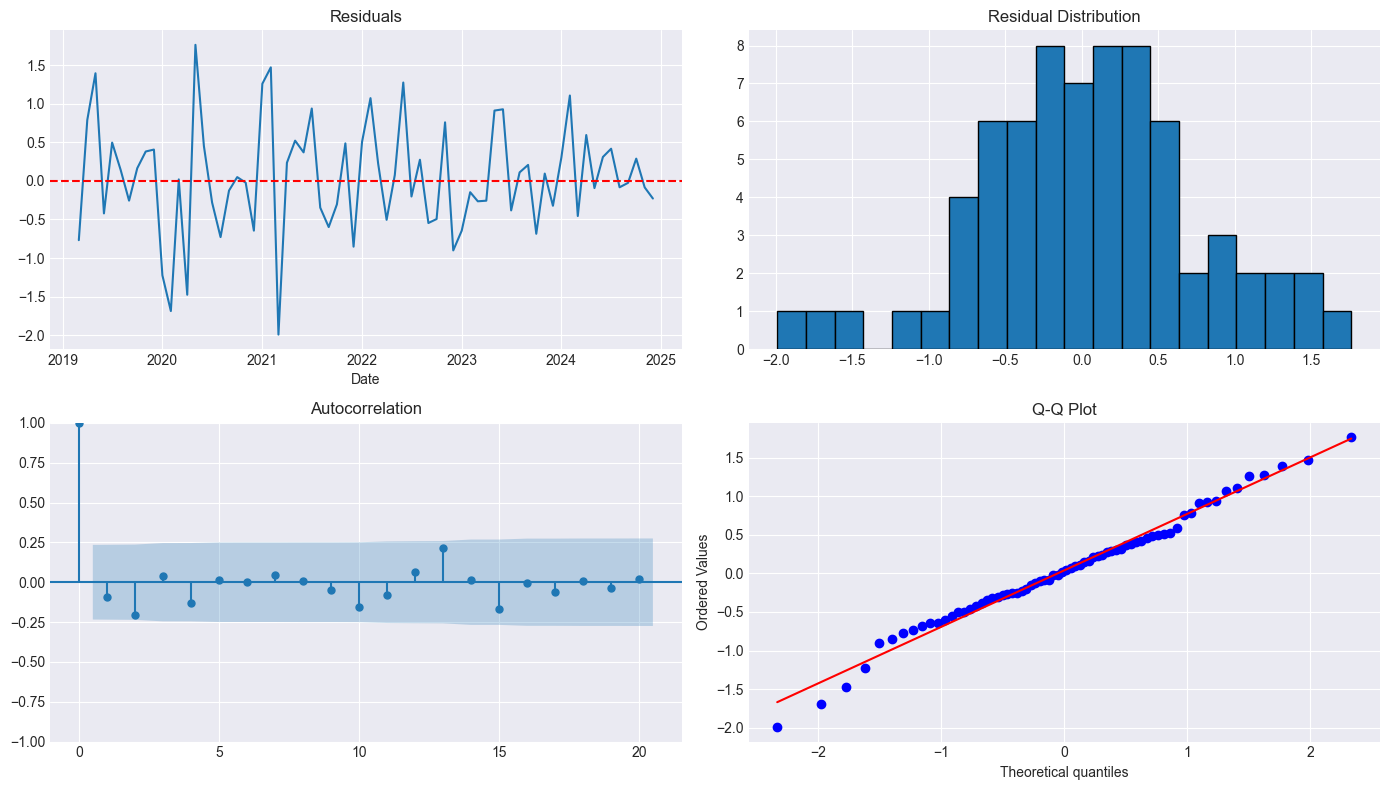


Residual diagnostics
Residual mean: 0.038749
Residual std:  0.717603
Jarque-Bera p-value: 0.700802


In [6]:
y_pred_scaled = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_test_actual = y_test.copy()

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

y_rw = df[target_col].shift(1).reindex(dates_test).values
mask = ~np.isnan(y_rw)
rmse_rw = np.sqrt(mean_squared_error(y_test_actual[mask], y_rw[mask]))
mae_rw = mean_absolute_error(y_test_actual[mask], y_rw[mask])
vs_rw = rmse / rmse_rw if rmse_rw > 0 else np.nan

y_mean = np.repeat(np.mean(y_test_actual), len(y_test_actual))
rmse_mean = np.sqrt(mean_squared_error(y_test_actual, y_mean))
vs_mean = rmse / rmse_mean if rmse_mean > 0 else np.nan

print("\nTest Results")
print(f"R²:                 {r2:.4f}")
print(f"RMSE:               {rmse:.6f}")
print(f"MAE:                {mae:.6f}")
print(f"Random Walk RMSE:   {rmse_rw:.6f}")
print(f"Random Walk MAE:    {mae_rw:.6f}")
print(f"Model / RW RMSE:    {vs_rw:.4f}")
print(f"Mean Baseline RMSE: {rmse_mean:.6f}")
print(f"Model / Mean RMSE:  {vs_mean:.4f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_test, y_test_actual, "o-", label="Actual", markersize=5, linewidth=2)
ax.plot(dates_test, y_pred, "s-", label="Predicted", markersize=4, linewidth=1.5, alpha=0.85)
ax.plot(dates_test[mask], y_rw[mask], "--", label="Random Walk", linewidth=1.4, alpha=0.75)
ax.set_title(f"{MODEL_NAME} Forecast | R²={r2:.4f} | RMSE={rmse:.6f} | Model/RW={vs_rw:.4f}")
ax.set_xlabel("Date")
ax.set_ylabel(target_col)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_forecast.png"), dpi=150)
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history["loss"], label="Train", linewidth=2)
ax1.plot(history.history["val_loss"], label="Validation", linewidth=2)
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel(LOSS_LABEL)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["mae"], label="Train", linewidth=2)
ax2.plot(history.history["val_mae"], label="Validation", linewidth=2)
ax2.set_title("MAE")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_training.png"), dpi=150)
plt.show()

residuals = y_test_actual - y_pred
max_lags = min(20, len(residuals) - 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(dates_test, residuals)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals")
axes[0, 0].set_xlabel("Date")
axes[0, 1].hist(residuals, bins=20, edgecolor="black")
axes[0, 1].set_title("Residual Distribution")
plot_acf(residuals, lags=max_lags, ax=axes[1, 0])
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_residuals.png"), dpi=150)
plt.show()

jb_stat, jb_p = jarque_bera(residuals)
print("\nResidual diagnostics")
print(f"Residual mean: {np.mean(residuals):.6f}")
print(f"Residual std:  {np.std(residuals):.6f}")
print(f"Jarque-Bera p-value: {jb_p:.6f}")